In [2]:
# Imports et chemin du fichier source
import pandas as pd

DATA_PATH = "../data/raw/online_retail_II.xlsx"

In [5]:
# 1. Chargement brut des deux années et concaténation
df_0910 = pd.read_excel(DATA_PATH, sheet_name="Year 2009-2010")
df_1011 = pd.read_excel(DATA_PATH, sheet_name="Year 2010-2011")

print("2009-2010:", df_0910.shape)
print("2010-2011:", df_1011.shape)

df = pd.concat([df_0910, df_1011], ignore_index=True)
print("Total concaténé:", df.shape)
df.info()

2009-2010: (525461, 8)
2010-2011: (541910, 8)
Total concaténé: (1067371, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [6]:
# 2. Vérifier la plage de dates couverte
print(df['InvoiceDate'].min(), "->", df['InvoiceDate'].max())

2009-12-01 07:45:00 -> 2011-12-09 12:50:00


In [7]:
# 3. Qualité : Customer ID manquants
n_missing = df['Customer ID'].isna().sum()
print(n_missing, "/", len(df), "=", round(n_missing/len(df)*100, 2), "%")

243007 / 1067371 = 22.77 %


In [8]:
# 4. Qualité : factures annulées (commencent par C)
cancel_mask = df['Invoice'].astype(str).str.startswith('C')
print(cancel_mask.sum(), "lignes soit", round(cancel_mask.mean()*100, 2), "%")

19494 lignes soit 1.83 %


In [9]:
# 5. Qualité : quantités négatives qui ne sont pas des annulations
neg_qty_no_cancel = df[(df['Quantity'] < 0) & (~cancel_mask)]
print(neg_qty_no_cancel.shape)
print(neg_qty_no_cancel[['Invoice','StockCode','Description','Quantity','Price','Customer ID']].head(15))

(3457, 8)
     Invoice StockCode      Description  Quantity  Price  Customer ID
263   489464     21733     85123a mixed       -96    0.0          NaN
283   489463     71477            short      -240    0.0          NaN
284   489467    85123A      21733 mixed      -192    0.0          NaN
470   489521     21646              NaN       -50    0.0          NaN
3114  489655     20683              NaN       -44    0.0          NaN
3162  489660     35956             lost     -1043    0.0          NaN
3168  489663    35605A          damages      -117    0.0          NaN
4296  489806     18010              NaN      -770    0.0          NaN
4538  489820     21133  invcd as 84879?      -720    0.0          NaN
4566  489821    85049G              NaN      -240    0.0          NaN
6556  489899   79323GR     sold as gold      -954    0.0          NaN
6576  489901     21098              NaN      -200    0.0          NaN
6911  490007     84347            21494      -720    0.0          NaN
7205  4900

In [10]:
# 6. Qualité : prix à 0 ou négatifs
print((df['Price'] <= 0).sum(), "lignes")
print(df.loc[df['Price'] <= 0, 'StockCode'].value_counts().head(10))

6207 lignes
StockCode
46000M    18
22501     18
79321     17
22423     16
21116     16
23084     16
22734     15
46000S    15
35965     14
22139     14
Name: count, dtype: int64


In [11]:
# 7. Repérer les codes qui ne sont pas de vrais produits (frais, ajustements, etc.)
print(df['StockCode'].astype(str).str.upper().value_counts().head(50))

StockCode
85123A    5930
22423     4424
85099B    4241
21212     3318
20725     3259
84879     2960
47566     2768
21232     2747
22197     2549
22383     2540
20727     2529
21931     2434
22386     2347
22469     2325
22411     2297
84991     2271
22382     2251
22384     2230
21080     2224
22086     2217
20914     2213
21034     2199
22139     2196
82494L    2196
21754     2192
20728     2185
22138     2154
22457     2152
20724     2138
POST      2122
22470     2117
82482     2116
21977     2092
20726     2050
21790     1988
85099C    1962
85099F    1943
22178     1934
21181     1920
84946     1904
21733     1903
22077     1858
22112     1847
22111     1846
22355     1832
22666     1810
21755     1798
20685     1786
22090     1752
21843     1734
Name: count, dtype: int64


In [12]:
# 8. Codes non-produits connus sur ce dataset (frais, ajustements, comptable)
codes_suspects = ['POST', 'D', 'M', 'C2', 'BANK CHARGES', 'DOT', 'CRUK', 'AMAZONFEE', 'PADS', 'ADJUST', 'ADJUST2']

mask_suspect = df['StockCode'].astype(str).str.upper().isin(codes_suspects)
print(mask_suspect.sum(), "lignes")
print(df.loc[mask_suspect, 'StockCode'].value_counts())
print(df.loc[mask_suspect, ['StockCode','Description']].drop_duplicates().head(20))

5703 lignes
StockCode
POST            2122
DOT             1446
M               1421
C2               282
D                177
BANK CHARGES     102
ADJUST            67
AMAZONFEE         43
PADS              19
CRUK              16
m                  5
ADJUST2            3
Name: count, dtype: int64
           StockCode                          Description
89              POST                              POSTAGE
735                D                             Discount
2379             DOT                       DOTCOM POSTAGE
2697               M                               Manual
9292              C2                             CARRIAGE
18410   BANK CHARGES                         Bank Charges
32207             C2                                  NaN
62299           PADS           PADS TO MATCH ALL CUSHIONS
70975         ADJUST  Adjustment by john on 26/01/2010 16
71058         ADJUST  Adjustment by john on 26/01/2010 17
96608              m                               Manual
1141

In [13]:
# 9. Vérifier si ces codes sont liés aux annulations ou aux clients manquants
suspect_detail = df[mask_suspect].groupby(df['StockCode'].astype(str).str.upper()).agg(
    nb_lignes=('StockCode', 'size'),
    pct_customer_id_manquant=('Customer ID', lambda x: round(x.isna().mean()*100, 1)),
    pct_annulation=('Invoice', lambda x: round(x.astype(str).str.startswith('C').mean()*100, 1)),
    prix_moyen=('Price', 'mean'),
)
print(suspect_detail)

              nb_lignes  pct_customer_id_manquant  pct_annulation   prix_moyen
StockCode                                                                     
ADJUST               67                       9.0            46.3   163.591343
ADJUST2               3                       0.0             0.0   243.683333
AMAZONFEE            43                     100.0            90.7  7646.089302
BANK CHARGES        102                      62.7            65.7   359.034422
C2                  282                       8.2             2.5    49.460993
CRUK                 16                       0.0           100.0   495.839375
D                   177                       1.7            97.2    72.867288
DOT                1446                      98.9             0.2   223.144876
M                  1426                      21.8            37.7   526.932784
PADS                 19                       0.0             5.3     1.927211
POST               2122                       4.9   

In [14]:
# 10. Zoom sur PADS — sa description ressemble à un vrai produit, à vérifier avant d'exclure
print(df[df['StockCode'].astype(str).str.upper()=='PADS'][['StockCode','Description','Quantity','Price','Customer ID']].head(20))

       StockCode                 Description  Quantity   Price  Customer ID
62299       PADS  PADS TO MATCH ALL CUSHIONS         1   0.001      16705.0
74731       PADS  PADS TO MATCH ALL CUSHIONS         1   0.001      13583.0
77702       PADS  PADS TO MATCH ALL CUSHIONS         1   0.001      17350.0
79794       PADS  PADS TO MATCH ALL CUSHIONS         1   0.001      13408.0
90798       PADS  PADS TO MATCH ALL CUSHIONS         1   0.001      13408.0
97716       PADS  PADS TO MATCH ALL CUSHIONS         1   0.001      15182.0
101718      PADS  PADS TO MATCH ALL CUSHIONS         1   0.001      13765.0
104480      PADS  PADS TO MATCH ALL CUSHIONS         1   0.001      14459.0
123947      PADS  PADS TO MATCH ALL CUSHIONS         1   0.001      14857.0
156809      PADS  PADS TO MATCH ALL CUSHIONS         1   0.001      12671.0
178629      PADS  PADS TO MATCH ALL CUSHIONS         1   0.001      14249.0
249035      PADS  PADS TO MATCH ALL CUSHIONS        -1  36.600      14459.0
341826      

In [16]:
# 12. Nettoyage final combinant tous les critères validés
# NB : filtre UK = décision de périmètre V1 (documentée), pas une correction de qualité de données
cancel_mask = df['Invoice'].astype(str).str.startswith('C')
suspect_mask = df['StockCode'].astype(str).str.upper().isin(codes_suspects)

df_clean = df[
    (~cancel_mask)
    & (~suspect_mask)
    & (df['Quantity'] > 0)
    & (df['Price'] > 0)
    & (df['Customer ID'].notna())
    & (df['Country'] == 'United Kingdom')
].copy()

df_clean['Customer ID'] = df_clean['Customer ID'].astype('int64')
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

print("Lignes brutes :", len(df))
print("Lignes propres (UK, clients identifiés, vraies ventes) :", len(df_clean))
print("Part conservée :", round(len(df_clean)/len(df)*100, 2), "%")
print("Nb clients uniques après nettoyage :", df_clean['Customer ID'].nunique())
print("CA total (période complète) : £", round(df_clean['TotalPrice'].sum(), 2))

Lignes brutes : 1067371
Lignes propres (UK, clients identifiés, vraies ventes) : 724452
Part conservée : 67.87 %
Nb clients uniques après nettoyage : 5334
CA total (période complète) : £ 14622284.2


In [17]:
# 13. StockCode mélange des int et des str (ex: 71053 vs "85123A") -> on uniformise en str
print(df_clean["StockCode"].map(type).value_counts())
df_clean["StockCode"] = df_clean["StockCode"].astype(str)

StockCode
<class 'int'>    642453
<class 'str'>     81999
Name: count, dtype: int64


In [20]:
# 14. Sauvegarde du jeu de données propre pour réutilisation (évite de refaire tout le nettoyage à chaque notebook)
import os

os.makedirs("../data/processed", exist_ok=True)

df_clean.to_parquet(
    "../data/processed/transactions_clean.parquet",
    engine="fastparquet",
    index=False
)
print("Sauvegardé :", df_clean.shape)

Sauvegardé : (724452, 9)


In [21]:
# 15. Une ligne par client x date d'achat (pas par ligne produit), écarts entre achats consécutifs
purchases = df_clean.groupby(['Customer ID', df_clean['InvoiceDate'].dt.date])['TotalPrice'].sum().reset_index()
purchases.columns = ['Customer ID', 'PurchaseDate', 'DayTotal']
purchases['PurchaseDate'] = pd.to_datetime(purchases['PurchaseDate'])
purchases = purchases.sort_values(['Customer ID', 'PurchaseDate'])

purchases['GapDays'] = purchases.groupby('Customer ID')['PurchaseDate'].diff().dt.days

gaps = purchases['GapDays'].dropna()

print("Nb d'écarts calculés :", len(gaps))
print(gaps.describe())
print()
print("Percentiles :")
for p in [50, 60, 70, 75, 80, 85, 90, 95, 99]:
    print(f"P{p} : {gaps.quantile(p/100):.1f} jours")

Nb d'écarts calculés : 24686
count    24686.000000
mean        59.712752
std         78.807075
min          1.000000
25%         13.000000
50%         32.000000
75%         71.000000
max        714.000000
Name: GapDays, dtype: float64

Percentiles :
P50 : 32.0 jours
P60 : 42.0 jours
P70 : 59.0 jours
P75 : 71.0 jours
P80 : 88.0 jours
P85 : 112.0 jours
P90 : 149.0 jours
P95 : 223.0 jours
P99 : 378.0 jours


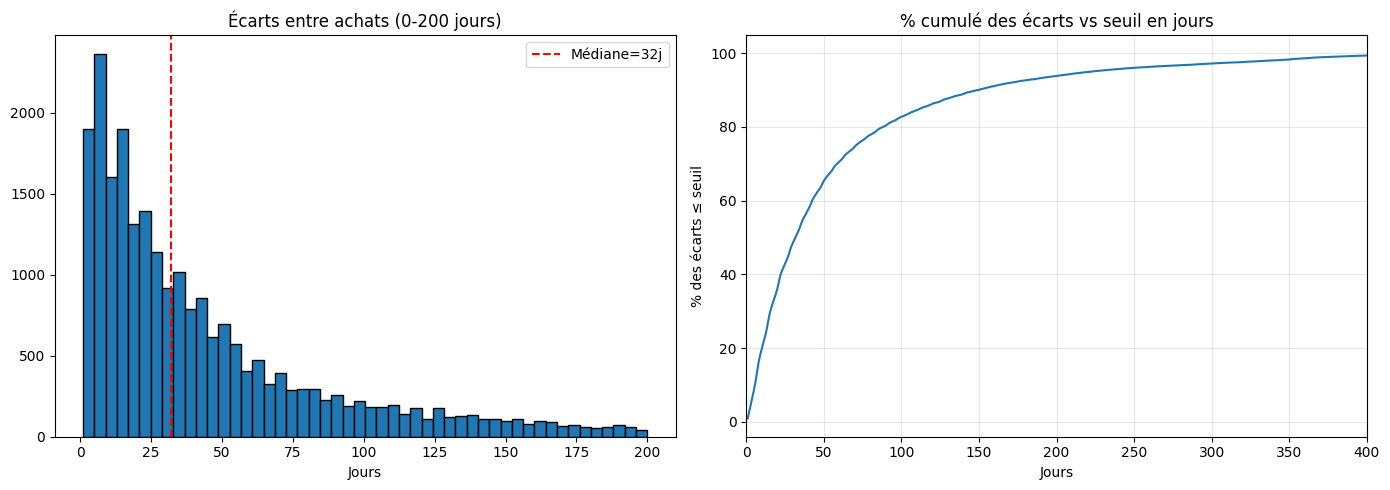

In [23]:
# 16. Visualiser la distribution des écarts entre achats
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vue 1 : histogramme zoomé 0-200 jours (là où se concentre l'essentiel)
axes[0].hist(gaps[gaps <= 200], bins=50, edgecolor='black')
axes[0].set_title("Écarts entre achats (0-200 jours)")
axes[0].set_xlabel("Jours")
axes[0].axvline(gaps.median(), color='red', linestyle='--', label=f'Médiane={gaps.median():.0f}j')
axes[0].legend()

# Vue 2 : courbe cumulative ("% de rachats couverts si on attend N jours")
sorted_gaps = gaps.sort_values()
cum_pct = (sorted_gaps.rank() / len(sorted_gaps)) * 100
axes[1].plot(sorted_gaps, cum_pct)
axes[1].set_title("% cumulé des écarts vs seuil en jours")
axes[1].set_xlabel("Jours")
axes[1].set_ylabel("% des écarts ≤ seuil")
axes[1].set_xlim(0, 400)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../docs/distribution_ecarts_achats.png", dpi=120)
plt.show()

In [24]:
# 17. Récence par rapport à la dernière date du fichier + test de plusieurs seuils
ref_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Date de référence :", ref_date)

last_purchase = df_clean.groupby('Customer ID')['InvoiceDate'].max().reset_index()
last_purchase.columns = ['Customer ID', 'LastPurchaseDate']
last_purchase['Recency'] = (ref_date - last_purchase['LastPurchaseDate']).dt.days

n_total = last_purchase.shape[0]
for seuil in [71, 90, 149, 180]:
    n_risque = (last_purchase['Recency'] > seuil).sum()
    print(f"Seuil {seuil}j : {n_risque} clients à risque / {n_total} = {round(n_risque/n_total*100,1)}%")

print()
print(last_purchase['Recency'].describe())

Date de référence : 2011-12-10 12:49:00
Seuil 71j : 2980 clients à risque / 5334 = 55.9%
Seuil 90j : 2724 clients à risque / 5334 = 51.1%
Seuil 149j : 2371 clients à risque / 5334 = 44.5%
Seuil 180j : 2195 clients à risque / 5334 = 41.2%

count    5334.000000
mean      202.570679
std       209.812510
min         1.000000
25%        26.000000
50%        97.000000
75%       381.000000
max       739.000000
Name: Recency, dtype: float64


In [25]:
# 18. Répartition des clients par date de première commande (pour choisir une coupure équilibrée)
first_purchase = df_clean.groupby('Customer ID')['InvoiceDate'].min().reset_index()
first_purchase.columns = ['Customer ID', 'FirstPurchaseDate']

monthly_new = first_purchase.groupby(first_purchase['FirstPurchaseDate'].dt.to_period('M')).size()
cum_pct = (monthly_new.cumsum() / first_purchase.shape[0] * 100).round(1)
print(cum_pct)

FirstPurchaseDate
2009-12     16.9
2010-01     23.3
2010-02     29.8
2010-03     37.4
2010-04     42.5
2010-05     46.9
2010-06     51.4
2010-07     54.5
2010-08     57.3
2010-09     61.3
2010-10     67.6
2010-11     73.4
2010-12     74.6
2011-01     75.7
2011-02     77.8
2011-03     80.9
2011-04     82.6
2011-05     84.4
2011-06     86.2
2011-07     87.9
2011-08     89.5
2011-09     92.7
2011-10     96.3
2011-11     99.6
2011-12    100.0
Freq: M, dtype: float64


In [26]:
# 19. Coupure temporelle : fenêtre d'observation vs fenêtre de label
cutoff = pd.Timestamp('2011-06-10')

obs = df_clean[df_clean['InvoiceDate'] < cutoff]
label_window = df_clean[df_clean['InvoiceDate'] >= cutoff]

eligible_customers = obs['Customer ID'].unique()
print("Clients éligibles (historique avant coupure) :", len(eligible_customers))

returned = label_window[label_window['Customer ID'].isin(eligible_customers)]['Customer ID'].unique()

churn_labels = pd.DataFrame({'Customer ID': eligible_customers})
churn_labels['Churned'] = ~churn_labels['Customer ID'].isin(returned)

n_churn = churn_labels['Churned'].sum()
n_total = churn_labels.shape[0]
print(f"Clients churnés : {n_churn} / {n_total} = {round(n_churn/n_total*100,1)}%")

Clients éligibles (historique avant coupure) : 4535
Clients churnés : 2187 / 4535 = 48.2%


In [27]:
# 20. Nb de commandes distinctes par client PENDANT la fenêtre d'observation
obs_freq = obs.groupby('Customer ID')['Invoice'].nunique().reset_index()
obs_freq.columns = ['Customer ID', 'NbCommandesObs']

churn_labels = churn_labels.merge(obs_freq, on='Customer ID')

print("Répartition du nb de commandes en observation :")
print(churn_labels['NbCommandesObs'].value_counts().sort_index().head(10))

print()
print("Taux de churn parmi les acheteurs UNIQUES (1 commande en obs) :")
one_timers = churn_labels[churn_labels['NbCommandesObs'] == 1]
print(f"{one_timers['Churned'].sum()} / {len(one_timers)} = {round(one_timers['Churned'].mean()*100,1)}%")

print()
print("Taux de churn parmi les clients avec 2+ commandes en obs (vrais 'réguliers') :")
repeaters = churn_labels[churn_labels['NbCommandesObs'] >= 2]
print(f"{repeaters['Churned'].sum()} / {len(repeaters)} = {round(repeaters['Churned'].mean()*100,1)}%")

Répartition du nb de commandes en observation :
NbCommandesObs
1     1410
2      776
3      503
4      373
5      269
6      199
7      173
8      131
9       99
10      94
Name: count, dtype: int64

Taux de churn parmi les acheteurs UNIQUES (1 commande en obs) :
1048 / 1410 = 74.3%

Taux de churn parmi les clients avec 2+ commandes en obs (vrais 'réguliers') :
1139 / 3125 = 36.4%


In [28]:
# 21. Taux de churn détaillé par nombre de commandes en observation
churn_by_freq = churn_labels.groupby('NbCommandesObs')['Churned'].agg(['mean','count'])
churn_by_freq['mean'] = (churn_by_freq['mean']*100).round(1)
print(churn_by_freq.head(12))

                mean  count
NbCommandesObs             
1               74.3   1410
2               58.9    776
3               46.9    503
4               43.2    373
5               32.7    269
6               30.7    199
7               24.3    173
8               19.8    131
9                8.1     99
10               9.6     94
11              20.3     74
12              11.3     53


In [29]:
# 22. Clients fidèles (≥3 commandes en observation) et leur taux de churn
loyal = churn_labels[churn_labels['NbCommandesObs'] >= 3]
n_churn_loyal = loyal['Churned'].sum()
n_loyal = len(loyal)
print(f"Clients fidèles (3+ commandes) : {n_loyal}")
print(f"Taux de churn parmi les fidèles : {n_churn_loyal} / {n_loyal} = {round(n_churn_loyal/n_loyal*100,1)}%")

Clients fidèles (3+ commandes) : 2349
Taux de churn parmi les fidèles : 682 / 2349 = 29.0%


In [30]:
# 23. Impact CA : combien les clients fidèles ont généré, et combien est "en péril"
ca_loyal = obs[obs['Customer ID'].isin(loyal['Customer ID'])]['TotalPrice'].sum()
churned_ids = loyal[loyal['Churned']]['Customer ID']
ca_churned_loyal = obs[obs['Customer ID'].isin(churned_ids)]['TotalPrice'].sum()

print(f"CA total généré par ces clients fidèles (en obs) : £{ca_loyal:,.0f}")
print(f"CA généré par ceux qui ont churné parmi eux : £{ca_churned_loyal:,.0f}")
print(f"Part du CA fidèle en péril : {round(ca_churned_loyal/ca_loyal*100,1)}%")

CA total généré par ces clients fidèles (en obs) : £9,304,170
CA généré par ceux qui ont churné parmi eux : £1,448,453
Part du CA fidèle en péril : 15.6%


In [ ]:
# 25. Sauvegarde des labels de churn pour réutilisation (notebook RFM notamment)
churn_labels['Fidele'] = churn_labels['NbCommandesObs'] >= 3
churn_labels.to_parquet("../data/processed/churn_labels.parquet", index=False)
print("Sauvegardé :", churn_labels.shape)
print(churn_labels['Fidele'].value_counts())

Sauvegardé : (4535, 4)
Fidele
True     2349
False    2186
Name: count, dtype: int64


: 